# PART 1: PREPROCESSING + Data Understanding

### Step 0: Import Libraries & Load Data
First, we need the tools to manipulate the table (Pandas) and do the math (Numpy).

In [ ]:
# First, we'll import pandas
import pandas as pd

# We'll also import seaborn, and matplotlib for visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score,KFold,RepeatedKFold,ShuffleSplit

import warnings 
warnings.filterwarnings("ignore")

In [3]:
# 1. Data Reading
dataset = pd.read_csv("StudentPerformanceFactors.csv")
# List of categorical columns and numerical columns
numerical_columns=dataset.select_dtypes(include=['int64']).columns.tolist() 
categorical_columns = dataset.select_dtypes(include=['object']).columns.tolist()
print("List of numerical columns:",numerical_columns)
print("List of categorical columns:",categorical_columns)
# Let's look at the first 5 rows to understand what our data looks like
print("First 5 rows of data:")
display(dataset.head())

# Let's check the types of data (numbers vs text) and total count
print("\nData Info:")
print(dataset.info())

List of numerical columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
List of categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
First 5 rows of data:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non

In [75]:
dataset.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


### Step 1: Data understanding


First let's see distribution of numerical columns

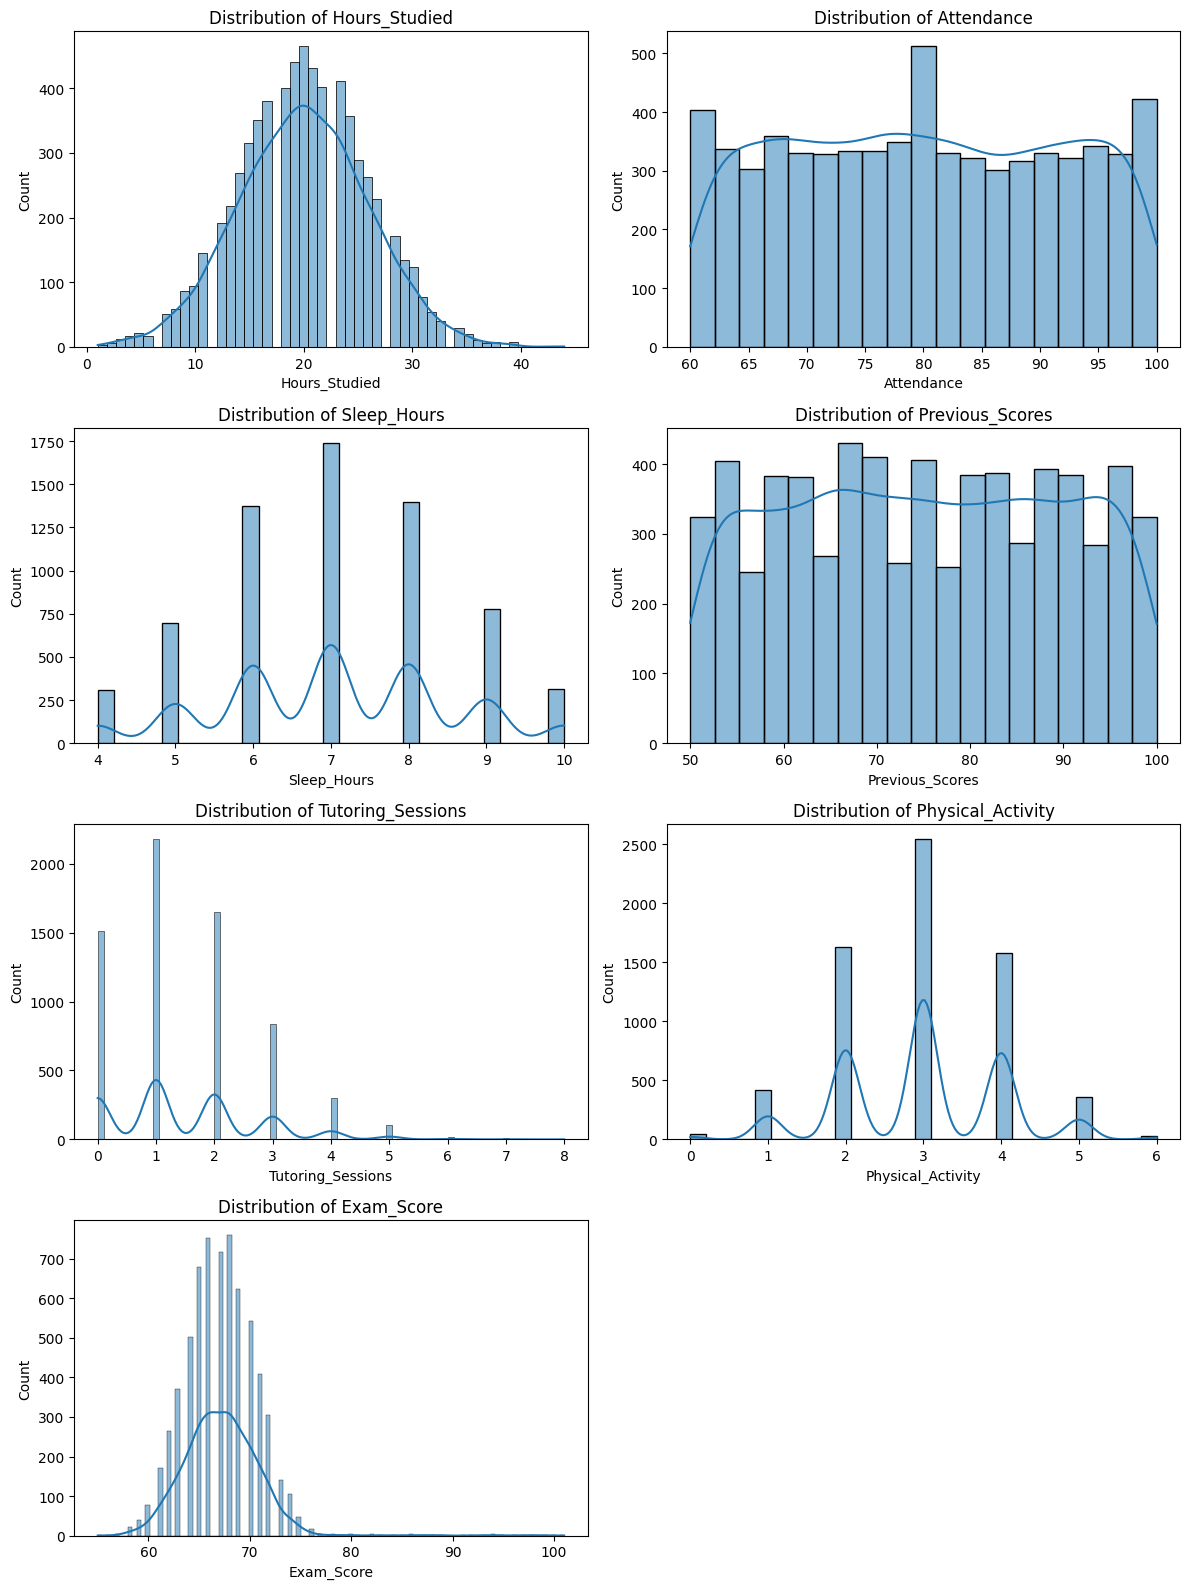

In [120]:
no_of_plots=2
no_of_rows=(len(numerical_columns)+1)//no_of_plots
fig=plt.figure(figsize=(12,4*no_of_rows))
for i,col in enumerate(numerical_columns):
    subplot_index=i+1
    plt.subplot(no_of_rows,no_of_plots,subplot_index)
    sns.histplot(dataset[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show() 

<Axes: xlabel='Parental_Involvement', ylabel='Exam_Score'>

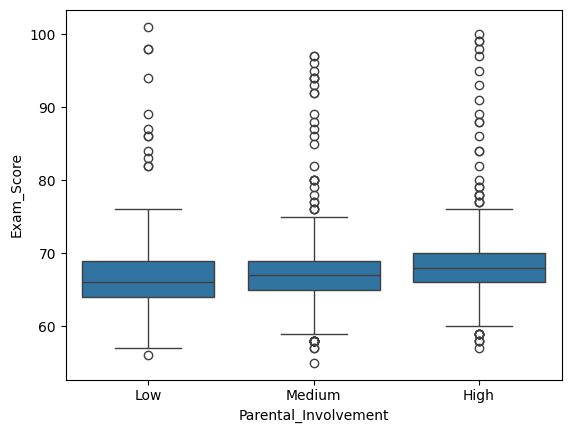

In [6]:
sns.boxplot(x = "Parental_Involvement", y = "Exam_Score", data = dataset)

Let's see the distribution of categorical columns

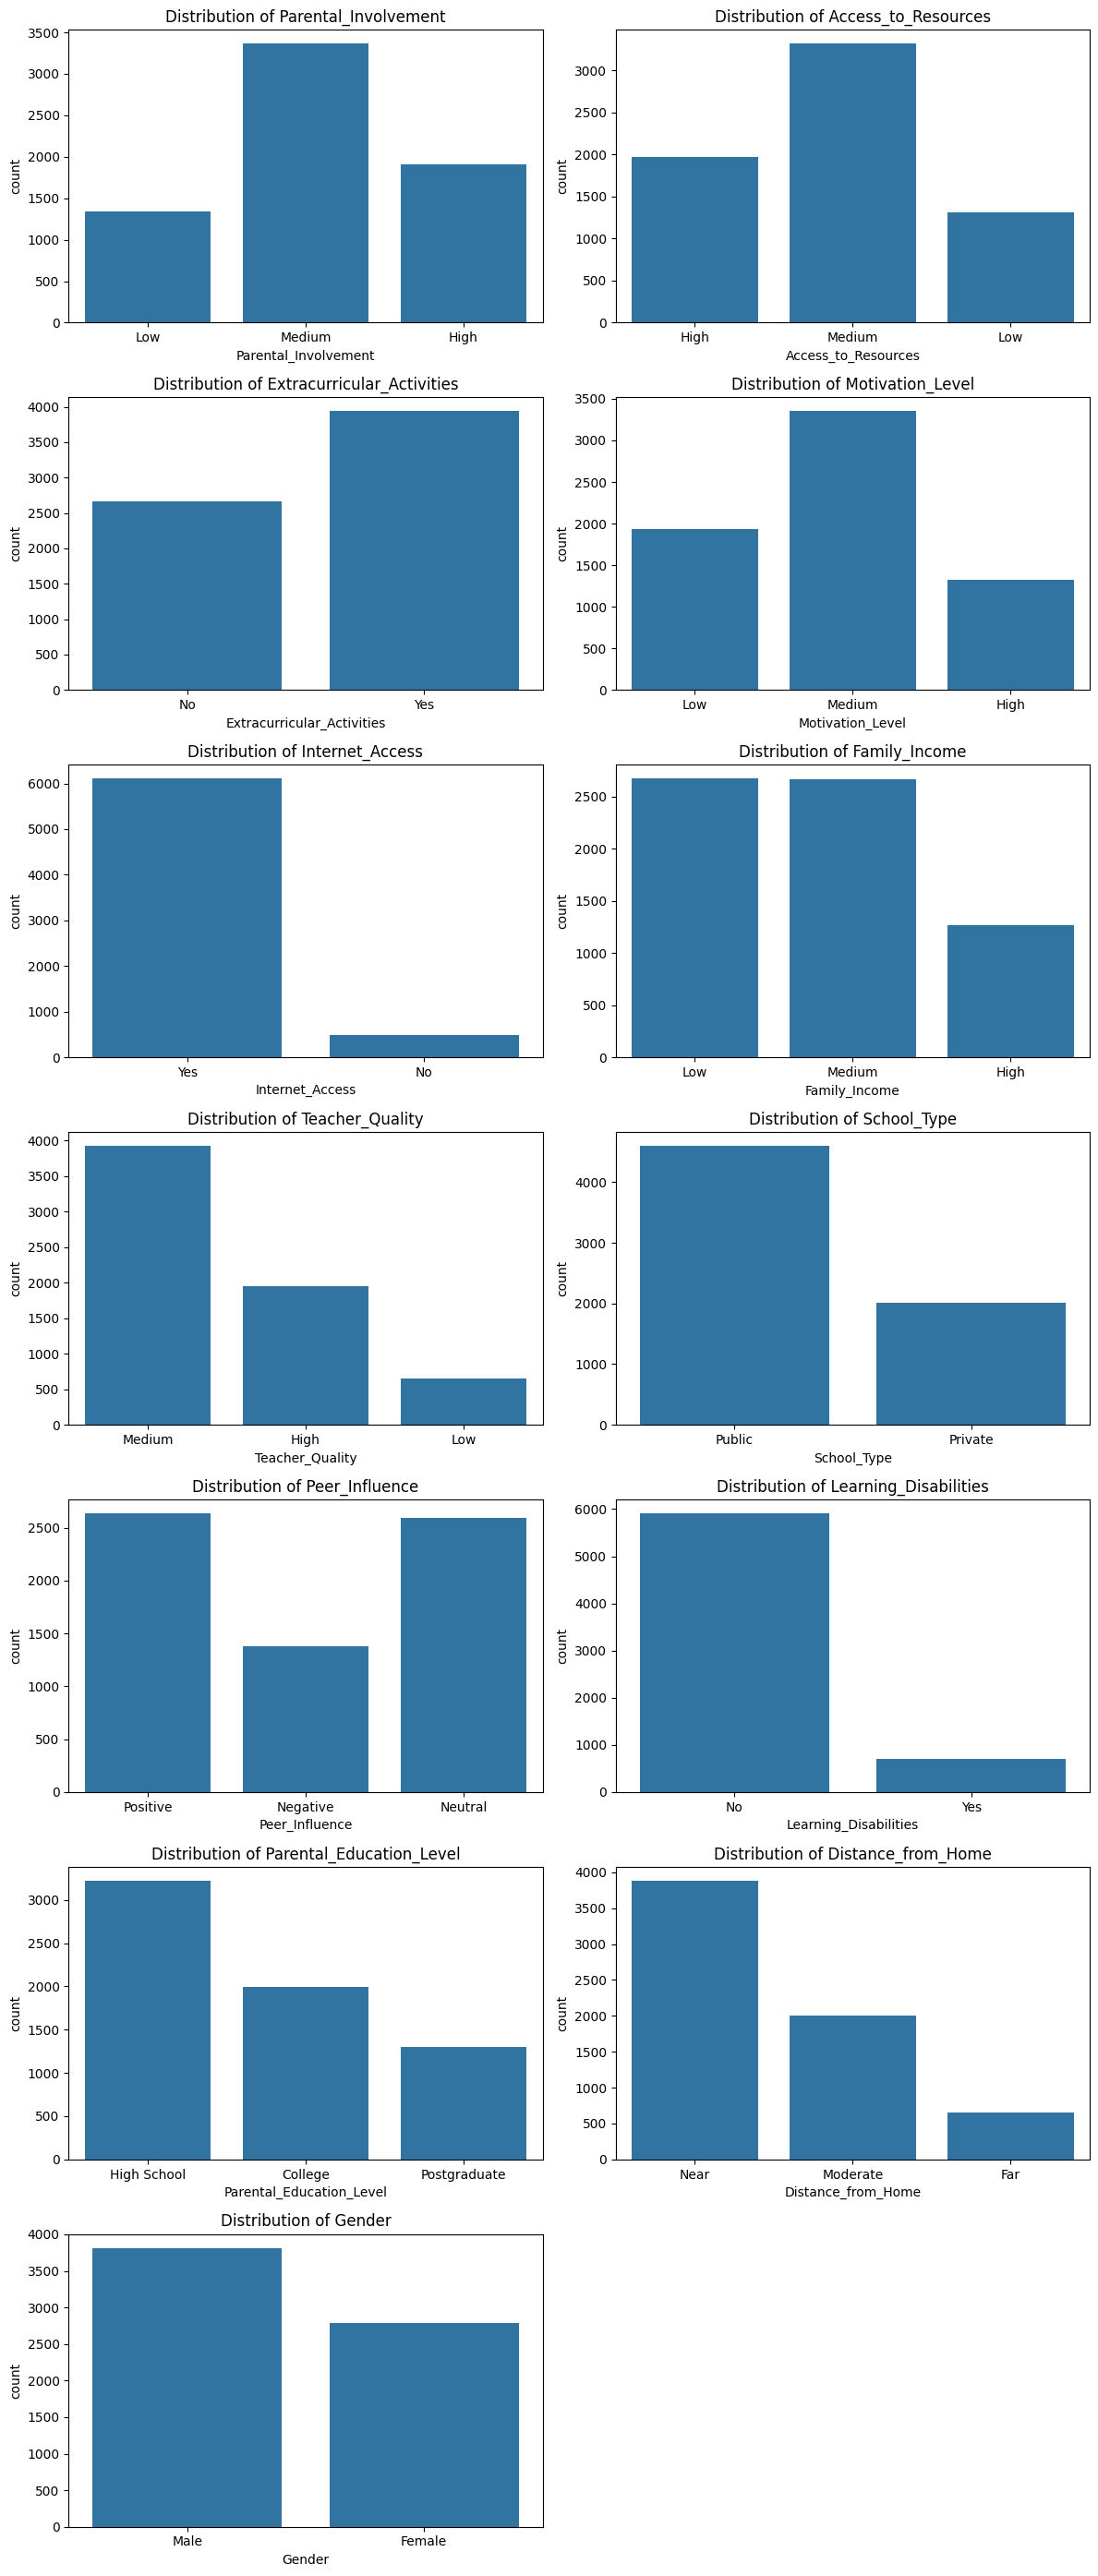

In [121]:
no_of_plots=2
no_of_rows=(len(categorical_columns)+1)//no_of_plots
fig=plt.figure(figsize=(12,4*no_of_rows))
for i,col in enumerate(categorical_columns):
    subplot_index=i+1
    plt.subplot(no_of_rows,no_of_plots,subplot_index)
    sns.countplot(data=dataset,x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show() 

<Axes: ylabel='Count'>

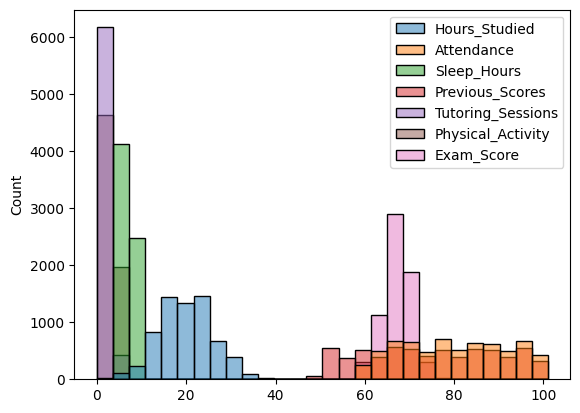

In [76]:
sns.histplot(data=dataset)

<Axes: xlabel='Tutoring_Sessions', ylabel='Count'>

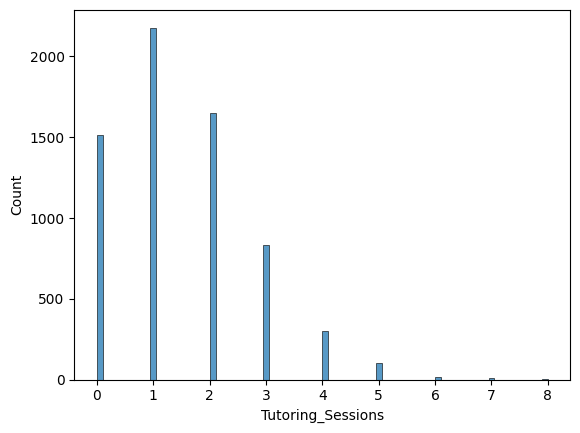

In [77]:
sns.histplot(data=dataset, x="Tutoring_Sessions")

In [78]:
# Descriptive Statistical Summary

dataset.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


In [79]:
dataset.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

### Step 2: Data Cleaning (Handling Missing Values)

In [80]:
# Detect missing values
print(dataset.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [81]:
# Detect missing value percentage
print(100 * dataset.isnull().sum() / len(dataset))

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64


In [83]:
# Data Cleaning 
# We check the most frequent value (index[0]) and fill the specific column with it.
dataset['Teacher_Quality'] = dataset['Teacher_Quality'].fillna(dataset['Teacher_Quality'].value_counts().index[0])
dataset['Parental_Education_Level'] = dataset['Parental_Education_Level'].fillna(dataset['Parental_Education_Level'].value_counts().index[0])
dataset['Distance_from_Home'] = dataset['Distance_from_Home'].fillna(dataset['Distance_from_Home'].value_counts().index[0])
# Check if any missing values remain
print("Missing values after cleaning:\n", dataset.isnull().sum())

Missing values after cleaning:
 Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [84]:
# Handling Duplicates
dataset = dataset.drop_duplicates()

### Step 3. Preprocessing 
Feature Encoding (Converting Categorical to Numerical Values), data assigning and splitting

#### SCENARIO A: LABEL ENCODING (Simple 0, 1, 2...)

In [95]:
print("\n=== RUNNING SCENARIO A: LABEL ENCODING ===")
df_le = dataset.copy()

# SHOW BEFORE ENCODING
print("--- BEFORE ENCODING (Categorical) ---")
print(df_le[['Parental_Involvement', 'Access_to_Resources']].head())

le = LabelEncoder()

for col in categorical_columns:
    df_le[col] = le.fit_transform(df_le[col])

X_le = df_le.drop('Exam_Score', axis=1)
y_le = df_le['Exam_Score']

# SHOW AFTER ENCODING
print("\n--- AFTER ENCODING (Numerical Values) ---")
print(df_le[['Parental_Involvement', 'Access_to_Resources']].head())

# Split (80/20 Split)
x_train_le, x_test_le, y_train_le, y_test_le = train_test_split(X_le, y_le, test_size=0.2, random_state=42)



=== RUNNING SCENARIO A: LABEL ENCODING ===
--- BEFORE ENCODING (Categorical) ---
  Parental_Involvement Access_to_Resources
0                  Low                High
1                  Low              Medium
2               Medium              Medium
3                  Low              Medium
4               Medium              Medium

--- AFTER ENCODING (Numerical Values) ---
   Parental_Involvement  Access_to_Resources
0                     1                    0
1                     1                    2
2                     2                    2
3                     1                    2
4                     2                    2


#### SCENARIO B: ONE-HOT ENCODING

In [96]:
print("\n=== RUNNING SCENARIO B: ONE-HOT ENCODING ===")
df_ohe = dataset.copy()
print(type(df_ohe))
# SHOW BEFORE ENCODING
print("--- BEFORE ENCODING (Categorical) ---")
print(df_ohe[['Parental_Involvement', 'Access_to_Resources']].head())

x_ohe = dataset.drop('Exam_Score', axis=1)
y_ohe = dataset['Exam_Score']
# 1. Split FIRST (Best practice for OHE to handle unknown categories safely) (80/20 Split)
x_train, x_test, y_train_ohe, y_test_ohe = train_test_split(x_ohe, y_ohe, test_size=0.2, random_state=42)

# 2. Apply get_dummies to x_train
x_train_ohe = pd.get_dummies(x_train, columns=categorical_columns, drop_first=True)
# 3. Apply get_dummies to x_test
x_test_ohe = pd.get_dummies(x_test, columns=categorical_columns, drop_first=True)
# If drop_first is true it does drop  redundant columns 

# SHOW AFTER ENCODING
print("\n--- AFTER ENCODING (Numerical Values) ---")
display(x_train_ohe.head())

# --- CRITICAL STEP: ALIGN COLUMNS ---
# This ensures x_test has the exact same columns as x_train in the same order.
# Any column in Train that is missing in Test will be added with 0s.
# Any column in Test that was not in Train will be dropped.
x_test_ohe = x_test_ohe.reindex(columns=x_train_ohe.columns, fill_value=0)

print("One-Hot Encoding Complete.")
print(f"New Feature Count: {x_train_ohe.shape[1]} columns (Previously 19)")


=== RUNNING SCENARIO B: ONE-HOT ENCODING ===
<class 'pandas.core.frame.DataFrame'>
--- BEFORE ENCODING (Categorical) ---
  Parental_Involvement Access_to_Resources
0                  Low                High
1                  Low              Medium
2               Medium              Medium
3                  Low              Medium
4               Medium              Medium

--- AFTER ENCODING (Numerical Values) ---


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
5810,27,79,8,63,2,5,True,False,False,False,...,True,True,False,False,False,False,False,True,False,False
1268,16,86,7,94,2,3,False,False,False,True,...,False,True,True,False,False,True,False,True,False,False
414,22,87,8,83,1,1,True,False,False,True,...,True,True,True,False,False,False,False,False,False,True
4745,18,100,10,86,1,3,False,False,False,True,...,True,True,True,False,False,True,False,False,True,True
654,35,78,10,99,1,2,False,False,True,False,...,True,False,False,True,False,True,False,False,True,True


One-Hot Encoding Complete.
New Feature Count: 27 columns (Previously 19)


### Step 4. Standardization & Normalization


In [97]:
set_config(transform_output="pandas")
norm = ["Tutoring_Sessions"]
stand = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Physical_Activity"]
preprocessor = ColumnTransformer(
    transformers=[
        ('norm', MinMaxScaler(), norm),
        ('stand', StandardScaler(), stand)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
x_train_le = preprocessor.fit_transform(x_train_le)
x_train_ohe = preprocessor.fit_transform(x_train_ohe)
x_test_le = preprocessor.fit_transform(x_test_le)
x_test_ohe = preprocessor.fit_transform(x_test_ohe)


In [98]:
x_test_le

,Tutoring_Sessions,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Physical_Activity,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
743,0.166667,-0.001391,-0.806181,-0.031624,0.827390,1.995766,2,1,0,0,1,2,2,1,0,0,1,2,1
5551,0.333333,0.333072,-0.806181,-0.031624,1.592730,-0.944504,2,1,1,1,1,1,0,1,1,0,1,1,0
3442,0.166667,0.165840,0.910451,-0.695231,-1.538206,0.035586,0,2,1,0,1,2,2,1,2,0,2,2,0
6571,0.000000,-1.339246,0.910451,0.631982,0.409932,1.015676,2,1,1,1,1,1,1,1,2,0,1,1,1
4204,0.333333,0.165840,-1.492834,0.631982,1.384001,1.995766,1,0,1,2,1,0,2,1,1,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4709,0.166667,-0.001391,-0.205360,1.959195,0.688237,0.035586,0,2,1,2,1,0,0,0,0,0,1,2,1
3664,0.000000,1.169231,0.824620,-0.031624,1.175272,0.035586,0,0,0,2,1,1,2,0,1,0,1,2,0
5231,0.166667,0.500304,-0.720349,-0.695231,-0.981595,1.995766,1,2,0,0,1,0,2,1,2,0,1,2,1
1773,0.333333,0.165840,-0.377023,-0.695231,-1.746935,1.015676,1,2,0,1,1,1,2,1,0,0,2,1,0


# PART 2: MODEL IMPLEMENTATION

### MODEL 1: LINEAR REGRESSION

In [99]:
# LABEL ENCODING Train & Predict (Linear Regression)
reg_le = LinearRegression()
reg_le.fit(x_train_le, y_train_le)
reg_pred_le = reg_le.predict(x_test_le)
# ONE-HOT ENCODING Train & Predict (Linear Regression)
reg_ohe = LinearRegression()
reg_ohe.fit(x_train_ohe, y_train_ohe)
reg_pred_ohe = reg_ohe.predict(x_test_ohe)

#### Gradient Descent On ONE-HOT ENCODING

In [103]:
# GRADIENT DESCENT
def gradient_descent(x, y, theta, iterations, alpha):
    past_costs = []
    past_thetas = [theta]
    for i in range(iterations):
        prediction = np.dot(x, theta)
        error = prediction - y
        # m must be defined in the global scope
        cost = 1/(2*m) * np.dot(error.T, error)
        past_costs.append(cost)
        theta = theta - (alpha * (1/m) * np.dot(x.T, error))
        past_thetas.append(theta)
        
    return past_thetas, past_costs
# 2. Data Preparation for Gradient Descent
# We use the Scaled One-Hot Encoded data (x_train_ohe, x_test_ohe)

# A. Convert Y to numpy array to avoid index mismatch errors
y_train_gd = y_train_ohe.values
y_test_gd = y_test_ohe.values

# B. Add a column of ones to X (Intercept/Bias term)
# For Train set
x_train_bias = np.c_[np.ones(x_train_ohe.shape[0]), x_train_ohe]
# For Test set
x_test_bias = np.c_[np.ones(x_test_ohe.shape[0]), x_test_ohe]

# 3. Initialize Variables
alpha = 0.001  # Learning Rate (Step size)
iterations = 10000 # No. of iterations
m = y_train_gd.size # No. of data points (Global variable required for the function)

np.random.seed(123) # Set seed for reproducibility
# Initialize theta with random values. 
# Size must match columns in x_train_bias (Features + 1 for intercept)
theta = np.random.rand(x_train_bias.shape[1]) 

# 4. Run Gradient Descent
print(f"Starting Gradient Descent with {iterations} iterations...")
past_thetas, past_costs = gradient_descent(x_train_bias, y_train_gd, theta, iterations, alpha)
final_theta = past_thetas[-1]

print("Gradient Descent Completed.")
print("Final Theta/Coefficients:", final_theta)

# 5. Prediction and Validation
# Make predictions on the Test set
y_pred_gd = np.dot(x_test_bias, final_theta)

Starting Gradient Descent with 10000 iterations...
Gradient Descent Completed.
Final Theta/Coefficients: [ 6.72121323e+01  1.75514966e+00  2.28993894e+00 -1.92621716e-02
  7.05062450e-01  6.26569355e-01  1.96325222e-01 -7.93511293e-01
 -5.24296346e-01 -8.29853366e-01 -5.07109997e-01  2.85770958e-01
 -4.53358230e-01 -2.54031548e-01  2.56896984e-01 -5.06594805e-01
 -2.75598313e-01 -2.99820906e-01 -2.69838026e-01  7.74081729e-03
  2.85609900e-01  5.27865489e-01 -2.67337138e-01 -2.25229482e-01
  2.08536669e-01  1.55876213e-01  4.28273956e-01 -1.34721315e-02]


### MODEL 2: KNN REGRESSION

In [90]:
# KNN with Label Encoding
knn_le = KNeighborsRegressor(n_neighbors=5)
knn_le.fit(x_train_le, y_train_le)
knn_pred_le = knn_le.predict(x_test_le)
# KNN with One-Hot Encoding (using scaled data)
knn_ohe = KNeighborsRegressor(n_neighbors=5)
knn_ohe.fit(x_train_ohe, y_train_ohe)
knn_pred_ohe = knn_ohe.predict(x_test_ohe)

# PART 3: MODEL VALIDATION (Results)

## Label Encoder vs One-Hot Result For Linear Legression 

In [91]:
print("\n================================================")
print("COMPARISON REPORT: Label Encoder vs One-Hot For linear regression")
print("================================================")

# Calculate Metrics
r2_le = r2_score(y_test_le, reg_pred_le)
mae_le = mean_absolute_error(y_test_le, reg_pred_le)
rmse_le = np.sqrt(mean_squared_error(y_test_le, reg_pred_le))

r2_ohe = r2_score(y_test_ohe, reg_pred_ohe)
mae_ohe = mean_absolute_error(y_test_ohe, reg_pred_ohe)
rmse_ohe = np.sqrt(mean_squared_error(y_test_ohe, reg_pred_ohe))

print(f"{'Metric':<10} | {'Label Encoding':<15} | {'One-Hot Encoding':<15}")
print("-" * 46)
print(f"{'R2 Score':<10} | {r2_le:<15.4f} | {r2_ohe:<15.4f}")
print(f"{'MAE':<10} | {mae_le:<15.4f} | {mae_ohe:<15.4f}")
print(f"{'RMSE':<10} | {rmse_le:<15.4f} | {rmse_ohe:<15.4f}")
print("-" * 46)

print("\nCONCLUSION: One-Hot Encoding improved the Linear Regression model!")



COMPARISON REPORT: Label Encoder vs One-Hot For linear regression
Metric     | Label Encoding  | One-Hot Encoding
----------------------------------------------
R2 Score   | 0.6888          | 0.7696         
MAE        | 1.0155          | 0.4524         
RMSE       | 2.0974          | 1.8044         
----------------------------------------------

CONCLUSION: One-Hot Encoding improved the Linear Regression model!


## Gradient Descent Results (One-Hot)

In [104]:
# Calculate Metrics
mse_gd = mean_squared_error(y_test_gd, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)
mae_gd = mean_absolute_error(y_test_gd, y_pred_gd)
r2_gd = r2_score(y_test_gd, y_pred_gd)

print("\n=== GRADIENT DESCENT RESULTS (One-Hot) ===")
print(f"{'Metric':<10} | {'Value':<15}")
print("-" * 26)
print(f"{'R2 Score':<10} | {r2_gd:<15.4f}")
print(f"{'MAE':<10} | {mae_gd:<15.2f}")
print(f"{'RMSE':<10} | {rmse_gd:<15.2f}")
print("-" * 26)


=== GRADIENT DESCENT RESULTS (One-Hot) ===
Metric     | Value          
--------------------------
R2 Score   | 0.7700         
MAE        | 0.45           
RMSE       | 1.80           
--------------------------


First cost: 2221.903243731278
Last cost:  2.1747844956706284


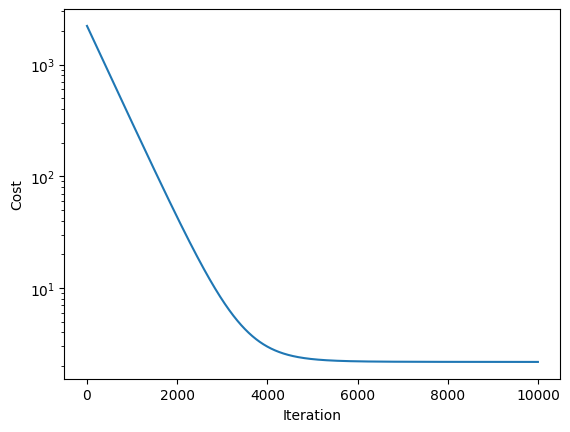

In [105]:
# Cost check
print("First cost:", past_costs[0])
print("Last cost: ", past_costs[-1])

# Simple plot
import matplotlib.pyplot as plt
plt.plot(past_costs)
plt.yscale('log')   # optional, makes convergence easier to read
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.show()

## Label Encoder vs One-Hot Results For KNN regression

In [92]:
print("\n================================================")
print("COMPARISON REPORT: Label Encoder vs One-Hot For KNN regression")
print("================================================")

# Calculate Metrics
r2_le = r2_score(y_test_le, knn_pred_le)
mae_le = mean_absolute_error(y_test_le, knn_pred_le)
rmse_le = np.sqrt(mean_squared_error(y_test_le, knn_pred_le))

r2_ohe = r2_score(y_test_ohe, knn_pred_ohe)
mae_ohe = mean_absolute_error(y_test_ohe, knn_pred_ohe)
rmse_ohe = np.sqrt(mean_squared_error(y_test_ohe, knn_pred_ohe))

print(f"{'Metric':<10} | {'Label Encoding':<15} | {'One-Hot Encoding':<15}")
print("-" * 46)
print(f"{'R2 Score':<10} | {r2_le:<15.4f} | {r2_ohe:<15.4f}")
print(f"{'MAE':<10} | {mae_le:<15.4f} | {mae_ohe:<15.4f}")
print(f"{'RMSE':<10} | {rmse_le:<15.4f} | {rmse_ohe:<15.4f}")
print("-" * 46)

print("\nCONCLUSION: Label Encoding actually performed better/similar here for the KNN model.")


COMPARISON REPORT: Label Encoder vs One-Hot For KNN regression
Metric     | Label Encoding  | One-Hot Encoding
----------------------------------------------
R2 Score   | 0.4599          | 0.4279         
MAE        | 1.7638          | 1.8891         
RMSE       | 2.7629          | 2.8437         
----------------------------------------------

CONCLUSION: Label Encoding actually performed better/similar here for the KNN model.


# PART 4: HyperParameter Tuning For KNN

In [107]:
# Define parameters to search (from the lab)
parameters = {
    'n_neighbors': np.arange(5, 10, 2),
    'weights' : ['uniform', 'distance'],
    'algorithm' : ['auto', 'kd_tree'],
    'leaf_size': np.arange(30, 50, 1),
    'p' : (1, 2) # p=1 for manhattan, p=2 for euclidean
}

# Initialize Grid Search
knn_grid = GridSearchCV(estimator = KNeighborsRegressor(),
                        param_grid = parameters,
                        cv = 5, 
                        scoring = 'neg_mean_squared_error',
                        n_jobs = -1)

# Fit using your SCALED training data
knn_grid.fit(x_train_ohe, y_train_ohe)

print("\nBest Parameters: ", knn_grid.best_params_)
print("Best Scores: ", knn_grid.best_score_) 

# Predict using the best model found
best_model = knn_grid.best_estimator_
y_pred_grid = best_model.predict(x_test_ohe)

# Print metrics for the optimized model
print("\n--- Optimized KNN Metrics ---")
print("R2 Score: ",round(r2_score(y_test_ohe, y_pred_grid),2))
print("Mean Squared Error: ", round(mean_squared_error(y_test_ohe, y_pred_grid), 2))
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y_test_ohe, y_pred_grid)), 2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test_ohe, y_pred_grid), 2))


Best Parameters:  {'algorithm': 'auto', 'leaf_size': np.int64(30), 'n_neighbors': np.int64(9), 'p': 2, 'weights': 'distance'}
Best Scores:  -9.142493123684465

--- Optimized KNN Metrics ---
R2 Score:  0.46
Mean Squared Error:  7.65
Root Mean Squared Error:  2.77
Mean Absolute Error:  1.83


# PART 5: Cross-Validation For LR And KNN

## A) Linear Rgression Cross-Validation

### Classic CV

In [109]:
R2s_CV = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = 7, scoring = 'r2')
MAEs_CV = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = 7, scoring = 'neg_mean_absolute_error')
RMSEs_CV = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = 7, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after Cross Validations : ", round(np.mean(R2s_CV), 5))
print("Average Mean Absolute Error after Cross Validations : ", round(np.mean(MAEs_CV), 5))
print("Average Root Mean Squared Error after Cross Validations : ", round(np.mean(RMSEs_CV), 5))

Average R2 score after Cross Validations :  0.65226
Average Mean Absolute Error after Cross Validations :  -1.07841
Average Root Mean Squared Error after Cross Validations :  -2.30119


### K-Fold

In [96]:

folds = KFold(n_splits = 5, shuffle = True, random_state = 42)

R2s_folds = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = folds, scoring = 'r2')
MAEs_folds = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = folds, scoring = 'neg_mean_absolute_error')
RMSEs_folds = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = folds, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after K-Fold : ", round(np.mean(R2s_folds), 5))
print("Average Mean Absolute Error after K-Fold : ", round(np.mean(MAEs_folds), 5))
print("Average Root Mean Squared Error after K-Fold : ", round(np.mean(RMSEs_folds), 5))

Average R2 score after K-Fold :  0.64168
Average Mean Absolute Error after K-Fold :  -1.0785
Average Root Mean Squared Error after K-Fold :  -2.34647


### Shuffle Split

In [97]:

Shuffle_Split = ShuffleSplit(n_splits=5, test_size = 0.2, random_state = 42)

R2s_Shuffle_Split = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = Shuffle_Split, scoring = 'r2')
MAEs_Shuffle_Split = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = Shuffle_Split, scoring = 'neg_mean_absolute_error')
RMSEs_Shuffle_Split = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = Shuffle_Split, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after Shuffle_Split : ", round(np.mean(R2s_Shuffle_Split), 5))
print("Average Mean Absolute Error after Shuffle_Split : ", round(np.mean(MAEs_Shuffle_Split), 5))
print("Average Root Mean Squared Error after Shuffle_Split : ", round(np.mean(RMSEs_Shuffle_Split), 5))

Average R2 score after Shuffle_Split :  0.64809
Average Mean Absolute Error after Shuffle_Split :  -1.06168
Average Root Mean Squared Error after Shuffle_Split :  -2.31972


### Repeated K-Fold

In [98]:

rkfolds = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

R2s_rkfolds = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = rkfolds, scoring = 'r2')
MAEs_rkfolds = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = rkfolds, scoring = 'neg_mean_absolute_error')
RMSEs_rkfolds = cross_val_score(reg_ohe, x_train_le, y_train_le, cv = rkfolds, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after K-Fold : ", round(np.mean(R2s_rkfolds), 5))
print("Average Mean Absolute Error after K-Fold : ", round(np.mean(MAEs_rkfolds), 5))
print("Average Root Mean Squared Error after K-Fold : ", round(np.mean(RMSEs_rkfolds), 5))

Average R2 score after K-Fold :  0.64379
Average Mean Absolute Error after K-Fold :  -1.07916
Average Root Mean Squared Error after K-Fold :  -2.33695


## B) KNN Cross-Validation

### Classic CV

In [112]:
R2s_CV = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = 7, scoring = 'r2')
MAEs_CV = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = 7, scoring = 'neg_mean_absolute_error')
RMSEs_CV = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = 7, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after Cross Validations : ", round(np.mean(R2s_CV), 5))
print("Average Mean Absolute Error after Cross Validations : ", round(np.mean(MAEs_CV), 5))
print("Average Root Mean Squared Error after Cross Validations : ", round(np.mean(RMSEs_CV), 5))

Average R2 score after Cross Validations :  0.42871
Average Mean Absolute Error after Cross Validations :  -1.84571
Average Root Mean Squared Error after Cross Validations :  -2.96021


### K-Fold

In [113]:
folds = KFold(n_splits = 5, shuffle = True, random_state = 42)

R2s_folds = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = folds, scoring = 'r2')
MAEs_folds = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = folds, scoring = 'neg_mean_absolute_error')
RMSEs_folds = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = folds, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after K-Fold : ", round(np.mean(R2s_folds), 5))
print("Average Mean Absolute Error after K-Fold : ", round(np.mean(MAEs_folds), 5))
print("Average Root Mean Squared Error after K-Fold : ", round(np.mean(RMSEs_folds), 5))

Average R2 score after K-Fold :  0.42702
Average Mean Absolute Error after K-Fold :  -1.82721
Average Root Mean Squared Error after K-Fold :  -2.9673


### Shuffle Split

In [114]:
Shuffle_Split = ShuffleSplit(n_splits=5, test_size = 0.2, random_state = 42)

R2s_Shuffle_Split = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = Shuffle_Split, scoring = 'r2')
MAEs_Shuffle_Split = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = Shuffle_Split, scoring = 'neg_mean_absolute_error')
RMSEs_Shuffle_Split = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = Shuffle_Split, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after Shuffle_Split : ", round(np.mean(R2s_Shuffle_Split), 5))
print("Average Mean Absolute Error after Shuffle_Split : ", round(np.mean(MAEs_Shuffle_Split), 5))
print("Average Root Mean Squared Error after Shuffle_Split : ", round(np.mean(RMSEs_Shuffle_Split), 5))

# Repeated K-Fold

Average R2 score after Shuffle_Split :  0.4141
Average Mean Absolute Error after Shuffle_Split :  -1.84397
Average Root Mean Squared Error after Shuffle_Split :  -2.9927


### Repeated K-Fold

In [115]:
rkfolds = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

R2s_rkfolds = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = rkfolds, scoring = 'r2')
MAEs_rkfolds = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = rkfolds, scoring = 'neg_mean_absolute_error')
RMSEs_rkfolds = cross_val_score(knn_ohe, x_train_le, y_train_le, cv = rkfolds, scoring = 'neg_root_mean_squared_error')

print("Average R2 score after K-Fold : ", round(np.mean(R2s_rkfolds), 5))
print("Average Mean Absolute Error after K-Fold : ", round(np.mean(MAEs_rkfolds), 5))
print("Average Root Mean Squared Error after K-Fold : ", round(np.mean(RMSEs_rkfolds), 5))

Average R2 score after K-Fold :  0.42644
Average Mean Absolute Error after K-Fold :  -1.8388
Average Root Mean Squared Error after K-Fold :  -2.96795
